# Import Libraries

In [83]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error

from math import sqrt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet

import torch
import torch.nn as nn 

# Load dataset

In [84]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url)

# Explore the dataset

In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Month       144 non-null    str  
 1   Passengers  144 non-null    int64
dtypes: int64(1), str(1)
memory usage: 2.4 KB


In [86]:
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [87]:
df.describe()

,Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


# Convert the month column

In [88]:
df['Month'] = pd.to_datetime(df['Month'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       144 non-null    datetime64[us]
 1   Passengers  144 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 2.4 KB


In [89]:
df.set_index('Month')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       144 non-null    datetime64[us]
 1   Passengers  144 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 2.4 KB


# Time series decomposition

Time series decomposition is a statistical technique that breaks a time series into three core components: trend-cycle (long-term movement), seasonality (repeating short-term cycles), and residuals (random noise). It is used to interpret historical data, adjust for seasonal effects, and improve overall forecasting accuracy.

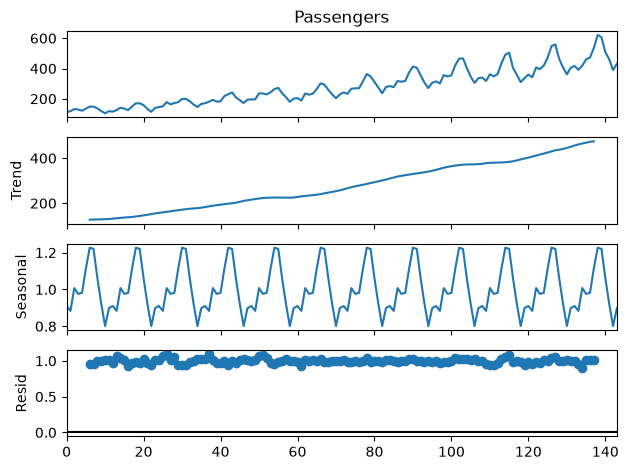

In [90]:
decomposition = seasonal_decompose(df["Passengers"], model="multiplicative", period=12)
decomposition.plot()
plt.show()

# Train test split

Time series should not be shuffled.

In [91]:
train = df.iloc[:-24]
test = df.iloc[-24:]

In [92]:
train

,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
115,1958-08-01,505
116,1958-09-01,404
117,1958-10-01,359
118,1958-11-01,310


In [93]:
test

,Month,Passengers
120,1959-01-01,360
121,1959-02-01,342
122,1959-03-01,406
123,1959-04-01,396
124,1959-05-01,420
125,1959-06-01,472
126,1959-07-01,548
127,1959-08-01,559
128,1959-09-01,463
129,1959-10-01,407


# Baseline forcast

naïve forecast (last observed value). Create a naive baseline forecast that assumes all future values will simply equal the very last known value from the training set.

In [57]:
#-1 targets the last row of the dataset. 0 targets the first column (the target variable to forecast).
# len(test): Calculates the total number of rows (the time steps) in test dataset. 
# If your test set spans 12 months, this equals 12.
# The * operator: In Python, multiplying a list by an integer does 
baseline = [train.iloc[-1,1]]*len(test)
baseline

[np.int64(337),
 np.int64(337),
 np.int64(337),
 np.int64(337),
 np.int64(337),
 np.int64(337),
 np.int64(337),
 np.int64(337),
 np.int64(337),
 np.int64(337),
 np.int64(337),
 np.int64(337),
 np.int64(337),
 np.int64(337),
 np.int64(337),
 np.int64(337),
 np.int64(337),
 np.int64(337),
 np.int64(337),
 np.int64(337),
 np.int64(337),
 np.int64(337),
 np.int64(337),
 np.int64(337)]

In [54]:
print(test.head())

         Month  Passengers
120 1959-01-01         360
121 1959-02-01         342
122 1959-03-01         406
123 1959-04-01         396
124 1959-05-01         420


In [56]:
test["Passengers"]

120    360
121    342
122    406
123    396
124    420
125    472
126    548
127    559
128    463
129    407
130    362
131    405
132    417
133    391
134    419
135    461
136    472
137    535
138    622
139    606
140    508
141    461
142    390
143    432
Name: Passengers, dtype: int64

In [58]:
mae_baseline = mean_absolute_error(test["Passengers"], baseline)
rmse_baseline = sqrt(mean_squared_error(test["Passengers"], baseline))

In [59]:
print(mae_baseline)

115.25


In [60]:
print(rmse_baseline)

137.32898455897794


# ARIMA

An ARIMA (Autoregressive Integrated Moving Average) model is a powerful statistical algorithm used for forecasting time series data. It works by capturing historical data patterns through three core components: Autoregression (AR), Differencing (I), and Moving Average (MA).

In [68]:
arima = ARIMA(train ["Passengers"], order = (5,1,0))
arima_model = arima.fit()
forcast_arima = arima_model.forecast(len(test["Passengers"]))
forcast_arima

120    390.436616
121    412.193788
122    418.256657
123    401.933514
124    379.237324
125    371.493515
126    374.279405
127    383.331769
128    392.088407
129    393.895717
130    390.775333
131    386.313674
132    383.293800
133    383.393321
134    385.382219
135    387.347977
136    388.213195
137    387.759136
138    386.716245
139    385.944482
140    385.793999
141    386.156238
142    386.640172
143    386.902351
Name: predicted_mean, dtype: float64

In [69]:
mae_arima = mean_absolute_error(test["Passengers"], forcast_arima)
rmse_arima= sqrt(mean_squared_error(test["Passengers"], forcast_arima))

In [70]:
mae_arima

75.89220671473699

In [71]:
rmse_arima

101.65923228779866

# SARIMA

SARIMA (Seasonal Autoregressive Integrated Moving Average) extends ARIMA by explicitly modeling seasonal patterns. It is the ideal choice for your airline passenger data because it handles both the overall upward trend and the repeating 12-month seasonal peaks.

In [75]:
sarima = SARIMAX(train["Passengers"], order=(1,1,1), seasonal_order=[1,1,1,12])
sarima_model = sarima.fit()
forcast_sarima = sarima_model.forecast(len(test["Passengers"]))

In [76]:
mae_sarima = mean_absolute_error(test["Passengers"], forcast_sarima)
rmse_sarima = sqrt(mean_squared_error(test["Passengers"], forcast_sarima))

In [77]:
mae_arima

75.89220671473699

In [78]:
rmse_sarima

73.4547083264614

# Prophet

Prophet is an open-source time series forecasting library developed by Meta (Facebook). It is designed to analyze data that contains strong seasonal patterns, multiple seasonality cycles (such as weekly and yearly), and structural trend shifts or holiday disruptions.

Unlike ARIMA or SARIMA models, which rely on the mathematical correlation between sequential data points, Prophet handles forecasting as a curve-fitting curve curve (additive regression model).

In [94]:
# Format the data to fit Prophet's strict naming conventions
# Copy the datasets to avoid modifying your original data variables
prophet_train = train[["Month", "Passengers"]].rename(
    columns={"Month": "ds", "Passengers": "y"}
)
prophet_test = test[["Month", "Passengers"]].rename(
    columns={"Month": "ds", "Passengers": "y"}
)

In [95]:
model_prophet = Prophet(yearly_seasonality=True)
model_prophet.fit(prophet_train)

14:44:38 - cmdstanpy - INFO - Chain [1] start processing
14:44:43 - cmdstanpy - INFO - Chain [1] done processing


In [109]:
# Build a dataframe containing only 'ds' columns for the test window
future_dates = prophet_test[["ds"]]

In [110]:
forecast_prophet = model_prophet.predict(future_dates)

In [111]:
forecast_prophet.info()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   ds                          24 non-null     datetime64[us]
 1   trend                       24 non-null     float64       
 2   yhat_lower                  24 non-null     float64       
 3   yhat_upper                  24 non-null     float64       
 4   trend_lower                 24 non-null     float64       
 5   trend_upper                 24 non-null     float64       
 6   additive_terms              24 non-null     float64       
 7   additive_terms_lower        24 non-null     float64       
 8   additive_terms_upper        24 non-null     float64       
 9   yearly                      24 non-null     float64       
 10  yearly_lower                24 non-null     float64       
 11  yearly_upper                24 non-null     float64       
 12  multipl

In [113]:
mae_prophet = mean_absolute_error(prophet_test["y"], forecast_prophet["yhat"])
rmse_prophet = sqrt(mean_squared_error(prophet_test["y"], forecast_prophet["yhat"]))

In [114]:
mae_prophet

31.162781327997322

In [115]:
rmse_prophet

40.39838464877204